In [ ]:
import numpy as np
import do_mpc
from utils.Dataclasses import Study
from casadi import vertcat
from dataclasses import asdict
from pprint import pprint
from tqdm import tqdm
import matplotlib.pyplot as plt

/home/janlc/miniconda3/envs/GeothermalSorption/lib/python3.14/site-packages/do_mpc/sysid/__init__.py:15: UserWarning: The ONNX feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The ONNX feature is not available. Please install the full version of do-mpc to access this feature.')
/home/janlc/miniconda3/envs/GeothermalSorption/lib/python3.14/site-packages/do_mpc/opcua/__init__.py:14: UserWarning: The opcua feature is not available. Please install the full version of do-mpc to access this feature.
  warnings.warn('The opcua feature is not available. Please install the full version of do-mpc to access this feature.')
/home/janlc/miniconda3/envs/GeothermalSorption/lib/python3.14/site-packages/do_mpc/approximateMPC/__init__.py:13: UserWarning: The approximateMPC feature requires PyTorch, which is not installed by default. Please install the full version of do-mpc to use this feature: pip install do_mpc[full]
  warnings.warn('The appr

In [ ]:
num_nodes = 10

In [ ]:
def model(num_nodes: int, study: Study) -> do_mpc.model.Model:
    '''
        Create a model for a fixed bed adsorption column.
        The model includes advection but not dispersion of the fluid phase.
    '''

    dx = study.column_parameters.Length / num_nodes

    model = do_mpc.model.Model('continuous')

    C_Li = model.set_variable('_x', 'C_Li', shape=(num_nodes,1)) # liquid phase concentration in mol/m^3
    n_i = model.set_variable('_x', 'n_i', shape=(num_nodes,1)) # adsorbed phase concentration in mol/kg

    dn_i_dt = study.kinetics_experiments[0].kinetics_params.k2_si * (study.isotherm.isotherm_fit.q_eq_si(C_Li, study.kinetics_experiments[0].T) - n_i)**2
    # dn_i_dt = study.kinetics_experiments[0].kinetics_params.k2_si * (10 - n_i)**2
    model.set_rhs('n_i', dn_i_dt)

    C_up = vertcat(study.column_parameters.influent_concentration_si, C_Li[:-1])  # Upstream concentration with boundary condition
    dC_Li_dt = - study.column_parameters.interstitial_velocity_si[0] / dx * (C_Li - C_up) - (1 - study.column_parameters.porosity) / study.column_parameters.porosity * study.sorbent_properties.density * dn_i_dt

    model.set_rhs('C_Li', dC_Li_dt)
    model.setup()
    return model



In [ ]:
s = Study.from_json('LiteratureReview/isotherm_kinetics.json', "jiangAdsorptionLithiumIons2020")
# print(s.column_parameters.influent_concentration_si)
s.isotherm.isotherm_fit.q_eq_si(50, 303)

0.0

In [ ]:
m = model(num_nodes, s)

In [ ]:
simulator = do_mpc.simulator.Simulator(m)
simulator.set_param(t_step=1.0)  # [s] time step for

simulator.setup()
simulator.reset_history()

simulator.x0['C_Li'] = np.zeros((num_nodes,1)) + .001
simulator.x0['n_i'] = np.zeros((num_nodes,1)) + .001

for i in tqdm(range(3*3600)):
    simulator.make_step()  # Advance the simulation by one time step
    

  0%|          | 0/10800 [00:00<?, ?it/s]

100%|██████████| 10800/10800 [00:09<00:00, 1124.93it/s]


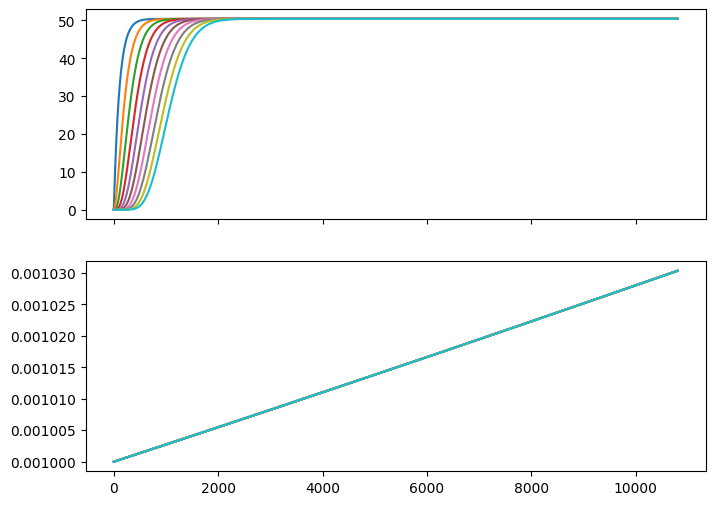

In [ ]:
graphics = do_mpc.graphics.Graphics(simulator.data)

fig, ax = plt.subplots(2,1, figsize=(8,6), sharex=True)
graphics.add_line(var_type='_x', var_name='C_Li', axis=ax[0], label='C_Li (mol/m^3)')
graphics.add_line(var_type='_x', var_name='n_i', axis=ax[1], label='n_i (mol/kg)')
